### **Task 1 — AI: AI-Based Intelligent System**

**Dataset**: Breast Cancer Wisconsin dataset from Scikit-learn

**Model**: Random Forest Classifier

**Purpose**: Build a simple intelligent system that accepts user input, predicts whether a sample is benign or malignant, and displays model performance.

AI TASK: INTELLIGENT CLASSIFICATION SYSTEM
------------------------------------------
Dataset: Breast Cancer Wisconsin Dataset
Total Samples: 569
Features: 30
Classes: ['malignant' 'benign']

First 5 Dataset Samples
-----------------------
 mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness  mean concavity  mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  area error  smoothness error  compactness error  concavity error  concave points error  symmetry error  fractal dimension error  worst radius  worst texture  worst perimeter  worst area  worst smoothness  worst compactness  worst concavity  worst concave points  worst symmetry  worst fractal dimension  target     class
       17.99         10.38          122.80     1001.0          0.11840           0.27760          0.3001              0.14710         0.2419                 0.07871        1.0950         0.9053            8.589      153.40     

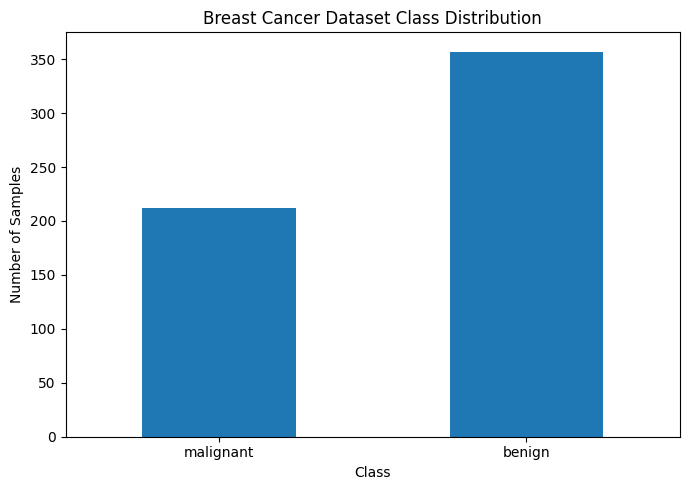


Model: Random Forest Classifier
Training Samples: 455
Testing Samples: 114
Model Training Completed.

Model Performance
-----------------
Accuracy: 94.74%

Classification Report
---------------------
              precision    recall  f1-score   support

   malignant     0.9286    0.9286    0.9286        42
      benign     0.9583    0.9583    0.9583        72

    accuracy                         0.9474       114
   macro avg     0.9435    0.9435    0.9435       114
weighted avg     0.9474    0.9474    0.9474       114



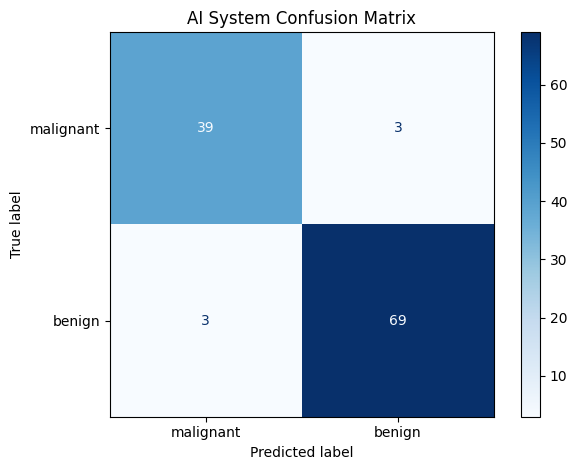

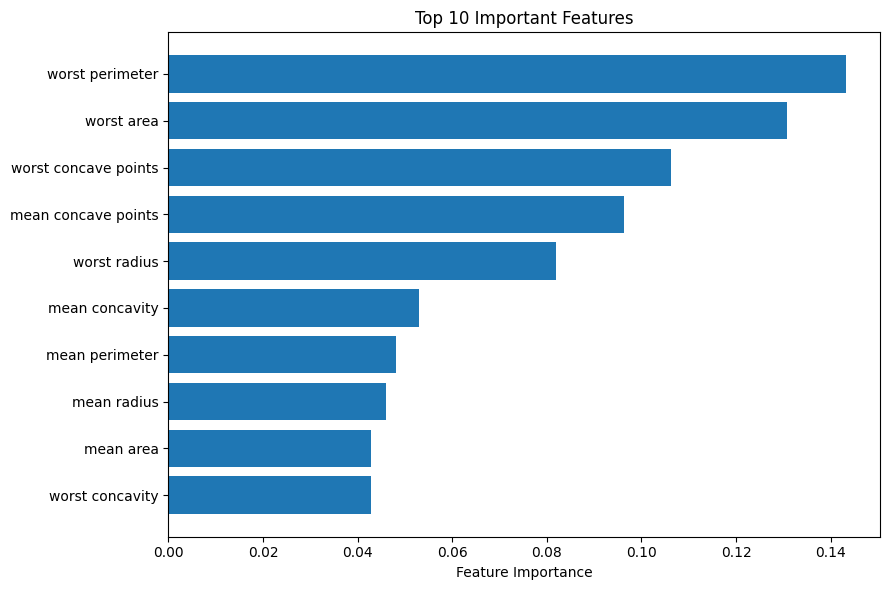


Sample Predictions
------------------
1. Actual: malignant | Predicted: malignant
2. Actual: benign | Predicted: benign
3. Actual: malignant | Predicted: malignant
4. Actual: benign | Predicted: malignant
5. Actual: malignant | Predicted: malignant

User Input Prediction
---------------------
Select a sample from the test dataset.
Enter a sample number from 1 to 114.
Sample number: 14

Prediction Result
-----------------
Predicted Class: malignant
Prediction Confidence: 100.00%

Task 1 Completed.


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df["class"] = data.target_names[y]

print("AI TASK: INTELLIGENT CLASSIFICATION SYSTEM")
print("------------------------------------------")
print("Dataset: Breast Cancer Wisconsin Dataset")
print("Total Samples:", len(df))
print("Features:", X.shape[1])
print("Classes:", data.target_names)

print("\nFirst 5 Dataset Samples")
print("-----------------------")
print(df.head().to_string(index=False))

print("\nDataset Information")
print("-------------------")
print("Missing Values:", int(df.isnull().sum().sum()))
print("Class Distribution:")
print(df["class"].value_counts().to_string())

df["class"].value_counts().reindex(data.target_names).plot(
    kind="bar",
    figsize=(7, 5)
)
plt.title("Breast Cancer Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel: Random Forest Classifier")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Model Training Completed.")

print("\nModel Performance")
print("-----------------")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report")
print("---------------------")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names,
    digits=4
))

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
).plot(cmap="Blues")

plt.title("AI System Confusion Matrix")
plt.tight_layout()
plt.show()

feature_importances = model.named_steps["classifier"].feature_importances_
top_indices = np.argsort(feature_importances)[-10:]

plt.figure(figsize=(9, 6))
plt.barh(
    data.feature_names[top_indices],
    feature_importances[top_indices]
)
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

print("\nSample Predictions")
print("------------------")

for i in range(5):
    print(
        f"{i + 1}. Actual: {data.target_names[y_test[i]]} | "
        f"Predicted: {data.target_names[y_pred[i]]}"
    )

print("\nUser Input Prediction")
print("---------------------")
print("Select a sample from the test dataset.")
print(f"Enter a sample number from 1 to {len(X_test)}.")

try:
    choice = int(input("Sample number: "))

    if 1 <= choice <= len(X_test):
        selected_sample = X_test[choice - 1].reshape(1, -1)

        prediction = model.predict(selected_sample)[0]
        probabilities = model.predict_proba(selected_sample)[0]

        print("\nPrediction Result")
        print("-----------------")
        print("Predicted Class:", data.target_names[prediction])
        print(f"Prediction Confidence: {max(probabilities) * 100:.2f}%")
    else:
        print(f"Invalid selection. Enter a number from 1 to {len(X_test)}.")

except ValueError:
    print("Invalid input. Please enter a whole number.")

print("\nTask 1 Completed.")

## **Task 2 — ML: Model Evaluation and Tuning**

**Dataset**: Breast Cancer Wisconsin dataset

**Models compared**: Logistic Regression, Decision Tree, Random Forest

**Tuning**: GridSearchCV with cross-validation

**Metrics**: Accuracy, precision, recall, F1 score, and ROC AUC

ML TASK: MODEL EVALUATION AND TUNING
------------------------------------
Dataset: Breast Cancer Wisconsin Dataset
Total Samples: 569
Features: 30

Model Comparison
----------------
              Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.9825     0.9861  0.9861    0.9861   0.9954
      Decision Tree    0.9123     0.9559  0.9028    0.9286   0.9157
      Random Forest    0.9561     0.9589  0.9722    0.9655   0.9937


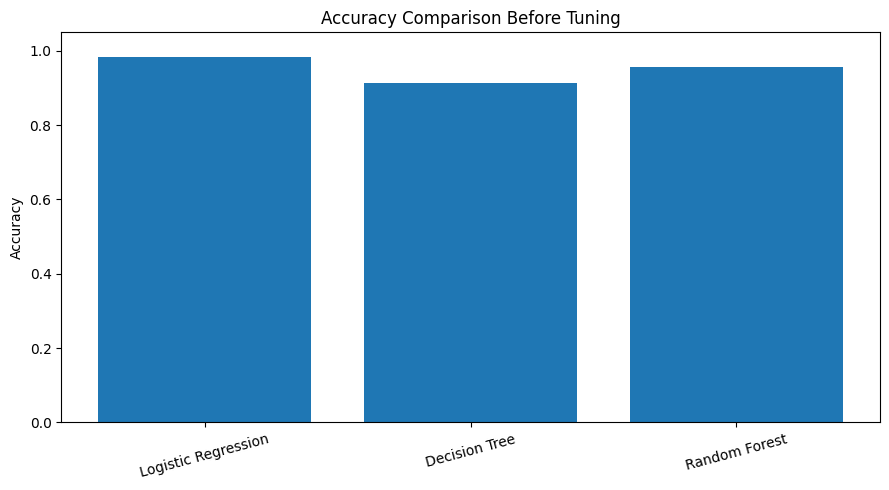


Tuned Logistic Regression
-------------------------
Best Parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}
Best Cross-Validation Accuracy: 98.24%
Test Accuracy: 98.25%
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861
ROC AUC: 0.9960


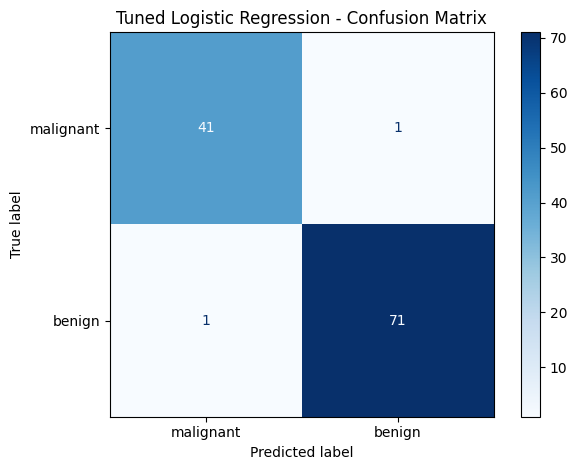

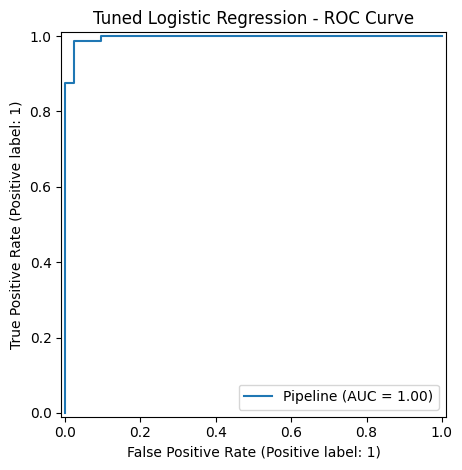

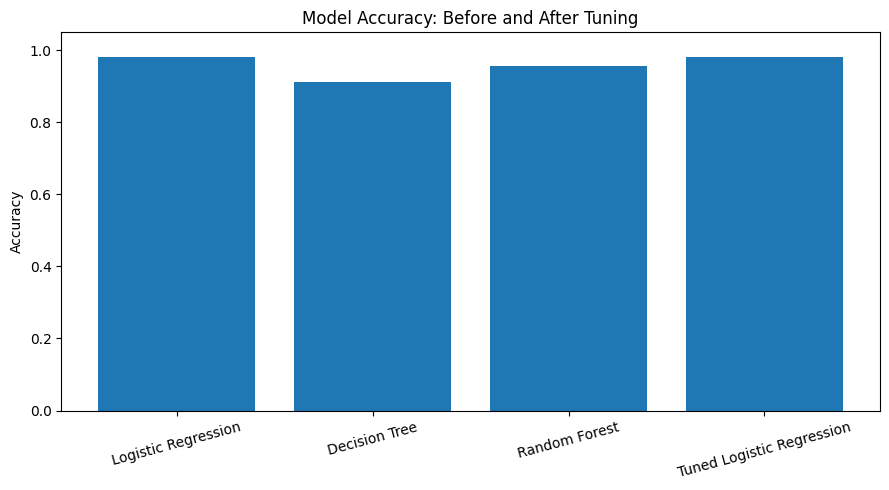


Sample Predictions After Tuning
--------------------------------
1. Actual: malignant | Predicted: malignant
2. Actual: benign | Predicted: benign
3. Actual: malignant | Predicted: malignant
4. Actual: benign | Predicted: benign
5. Actual: malignant | Predicted: malignant

Task 2 Completed.


In [2]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    RocCurveDisplay
)

data = load_breast_cancer()
X = data.data
y = data.target

print("ML TASK: MODEL EVALUATION AND TUNING")
print("------------------------------------")
print("Dataset: Breast Cancer Wisconsin Dataset")
print("Total Samples:", len(X))
print("Features:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

print("\nModel Comparison")
print("----------------")
print(results_df.round(4).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy Comparison Before Tuning")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

parameters = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

search = GridSearchCV(
    pipeline,
    parameters,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
tuned_predictions = best_model.predict(X_test)
tuned_probabilities = best_model.predict_proba(X_test)[:, 1]

print("\nTuned Logistic Regression")
print("-------------------------")
print("Best Parameters:", search.best_params_)
print(f"Best Cross-Validation Accuracy: {search.best_score_ * 100:.2f}%")
print(f"Test Accuracy: {accuracy_score(y_test, tuned_predictions) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, tuned_predictions):.4f}")
print(f"Recall: {recall_score(y_test, tuned_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test, tuned_predictions):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, tuned_probabilities):.4f}")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, tuned_predictions),
    display_labels=data.target_names
).plot(cmap="Blues")

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Tuned Logistic Regression - ROC Curve")
plt.tight_layout()
plt.show()

comparison = results_df.set_index("Model")["Accuracy"]
comparison.loc["Tuned Logistic Regression"] = accuracy_score(
    y_test, tuned_predictions
)

plt.figure(figsize=(9, 5))
plt.bar(comparison.index, comparison.values)
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Model Accuracy: Before and After Tuning")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nSample Predictions After Tuning")
print("--------------------------------")

for i in range(5):
    print(
        f"{i + 1}. Actual: {data.target_names[y_test[i]]} | "
        f"Predicted: {data.target_names[tuned_predictions[i]]}"
    )

print("\nTask 2 Completed.")
